In [115]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
from astropy.io import fits
import george,os,pdb,sys,random
from george.kernels import Matern32Kernel,ExpSquaredKernel
import scipy.optimize as op
import scipy.sparse as sp
import scipy.sparse.linalg as spla

In [202]:
#import data

SN_name="SN2010ev"#"SN2007cq"

if SN_name=="SN2010ev":
    z=0.00921
    ra, dec = 156.370792, -39.830889
    #target_snr = 250

file_name="../../DATA/"+SN_name+".fits"


data = fits.open(file_name)
cube = data[1].data   # this is the cube, a (3681 x 341 x 604) matrix with fluxes at different 3681 wavelengths and 308 x 318 spatial pixels ("spaxels")
header = data[1].header # this has information on the data cube
ecube = data[2].data # this is the cube uncertainty (3681 x 341 x 604)
print(np.shape(cube))


x_len=len(cube[0][0])
y_len=len(cube[0])

#  -- following is to the get the wavelength array
CRVAL = float(header["CRVAL3"])
NAXIS = int(header["NAXIS3"])
CDELT = float(header["CD3_3"])
CRPIX = float(header["CRPIX3"])
wave = np.array(CRVAL + CDELT * (np.arange(NAXIS) - CRPIX))

(3681, 341, 604)


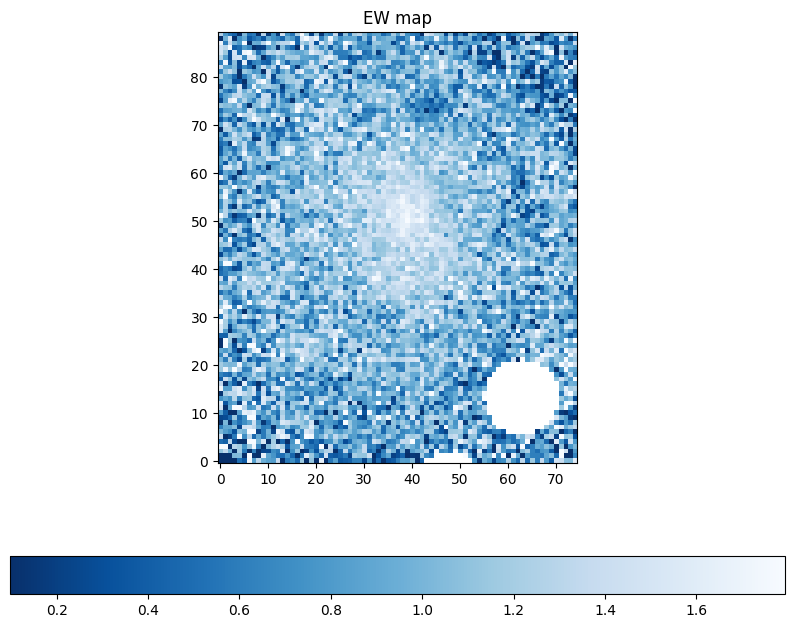

In [205]:
## dimensions
nw,ny,nx = cube.shape

## For now use the average cube as input image
#avg = np.mean(cube,axis=0)

## Use ew-map as input image
ew_map = np.load("ew_map.npy")
Av_map = np.load("Av_map.npy")


## Plot the ew_map
vmin, vmax = np.nanpercentile(ew_map, [2, 98])
ew_map_clipped = np.clip(ew_map, vmin, vmax)
lo, up = np.nanpercentile(ew_map, 2), np.nanpercentile(ew_map, 98)
plt.figure(figsize=(10, 8))
plt.imshow(ew_map_clipped, cmap='Blues_r', origin='lower', clim=(lo, up))
plt.colorbar(orientation="horizontal")
plt.title("EW map")
plt.show()

In [206]:
## Function to take out (=nan) a given percentage randomly of the image
def perc_img(img,perc):
    nx,ny = img.shape
    newimg = img.copy()
    for y in range(ny):
        for x in range(nx):
            if float(random.random()) < perc:
                newimg[x][y]=float("nan")
    return newimg

In [163]:
## Obtain an image with certain percentage
perc = 0.5 #
#navg = perc_img(avg,perc)
navg = perc_img(ew_map,perc)

## Get x y and img in format for GP (single array)
ny,nx = ew_map.shape #cube.shape
x,y = np.linspace(0,nx-1,nx), np.linspace(0,ny-1,ny)
xv,yv= np.meshgrid(x, y)
xgp,ygp,navggp = xv.reshape(-1), yv.reshape(-1), navg.reshape(-1)
xygp = np.stack((xgp,ygp),axis=1)

## Separate training (non-nan) and test (nan) sets
wtrain = np.isfinite(navggp)

## Kernel for GP
kernel = Matern32Kernel(0.5, ndim=2)
gp = george.GP(kernel)
gp.compute(xygp[wtrain])

In [169]:
## Optimize solution

# Define the objective function (negative log-likelihood in this case).
def nll(p):
    gp.set_parameter_vector(p)
    ll = gp.log_likelihood(navggp[wtrain], quiet=True)
    return -ll if np.isfinite(ll) else 1e25

# And the gradient of the objective function.
def grad_nll(p):
    gp.set_parameter_vector(p)
    return -gp.grad_log_likelihood(navggp[wtrain], quiet=True)

# Print the initial ln-likelihood.
print(gp.log_likelihood(navggp[wtrain]))

# Run the optimization routine.
p0 = gp.get_parameter_vector()
results = op.minimize(nll, p0, jac=grad_nll, method="L-BFGS-B")

# Update the kernel and print the final log-likelihood.
gp.set_parameter_vector(results.x)
print(gp.log_likelihood(navggp[wtrain]))

-3949.2902258905747
-2722.3688309022573


In [170]:
## Now predict
mugp, vargp = gp.predict(navggp[wtrain], xygp, return_var=True)

## Revert to image dimension
mu,var = mugp.reshape(ny,nx),vargp.reshape(ny,nx)

Text(0.5, 1.0, 'GP reconstruction')

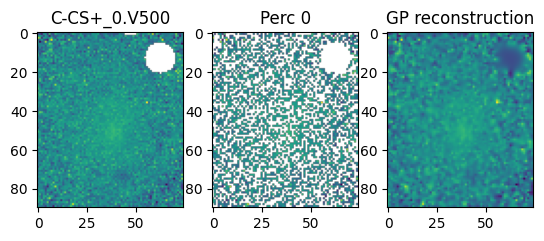

In [172]:
## Now compare new images
fig, axs = plt.subplots(1, 3)
lo,up = np.percentile(ew_map,1),np.percentile(ew_map,99)
axs[0].imshow(ew_map)#,clim=(lo,up))
axs[0].set_title('C-CS+_0.V500')
axs[1].imshow(navg)
axs[1].set_title('Perc %i' %perc)
axs[2].imshow(mu)
axs[2].set_title('GP reconstruction')


# GMRF

In [196]:
## Complete a 2D map using a GMRF (graph Laplacian) prior.

def gmrf_complete(Av_map):
    
    ny, nx = Av_map.shape
    N = ny * nx

    obs_mask = ~np.isnan(Av_map)
    idx = np.arange(N).reshape(ny, nx)

    # Build graph Laplacian for a 4-neighbor grid
    rows, cols = [], []
    for i in range(ny):
        for j in range(nx):
            k = idx[i, j]
            if i + 1 < ny:
                rows.append(k); cols.append(idx[i+1, j])
            if j + 1 < nx:
                rows.append(k); cols.append(idx[i, j+1])

    rows = np.array(rows); cols = np.array(cols)

    # Build sparse adjacency, then Laplacian Q = D - A
    A = sp.coo_matrix((np.ones(len(rows)), (rows, cols)), shape=(N, N))
    A = A + A.T  # symmetric
    D = sp.diags(np.array(A.sum(axis=1)).flatten())
    Q = (D - A).tocsr()

    # Partition into observed (o) and unobserved (u)
    obs_flat = obs_mask.flatten()
    u_idx = np.where(~obs_flat)[0]
    o_idx = np.where(obs_flat)[0]

    Q_uu = Q[u_idx][:, u_idx]
    Q_uo = Q[u_idx][:, o_idx]

    x_o = Av_map.flatten()[o_idx]

    # Conditional mean: Q_uu x_u = -Q_uo x_o
    rhs = -Q_uo @ x_o
    x_u = spla.spsolve(Q_uu.tocsc(), rhs)

    # Reassemble
    result = Av_map.flatten().copy()
    result[u_idx] = x_u
    return result.reshape(ny, nx)

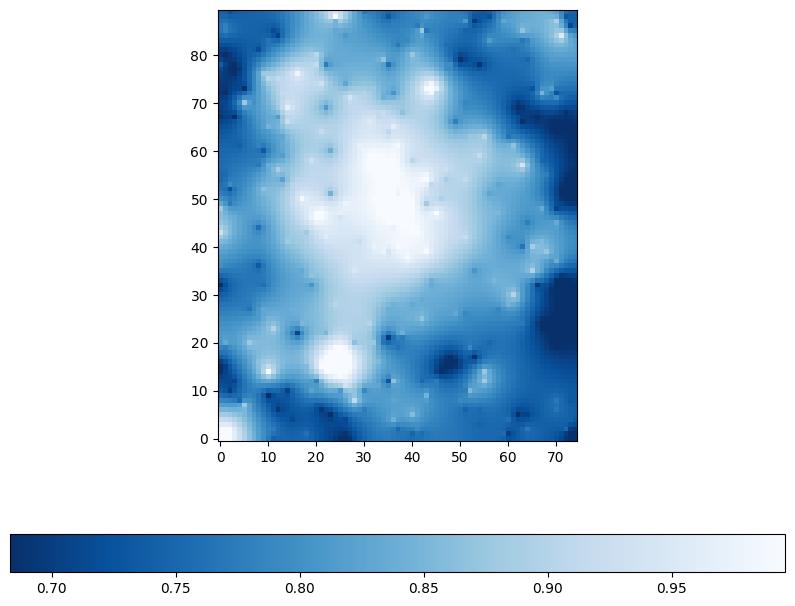

Text(0.5, 1.0, 'GP reconstruction')

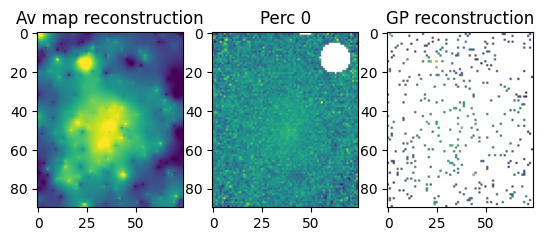

In [201]:
Av_map_complete = gmrf_complete(Av_map)


## Plot the ew_map
vmin, vmax = np.nanpercentile(Av_map_complete, [2, 98])

lo, up = np.nanpercentile(Av_map_complete, 2), np.nanpercentile(Av_map_complete, 98)
plt.figure(figsize=(10, 8))
plt.imshow(Av_map_complete, cmap='Blues_r', origin='lower', clim=(lo, up))
plt.colorbar(orientation="horizontal")
plt.show()

## Now compare new images
fig, axs = plt.subplots(1, 3)
lo,up = np.percentile(Av_map_complete,1),np.percentile(Av_map_complete,99)
axs[0].imshow(Av_map_complete,clim=(lo,up))
axs[0].set_title('Av map reconstruction')
axs[1].imshow(ew_map)
axs[1].set_title('Perc %i' %perc)
axs[2].imshow(Av_map)
axs[2].set_title('GP reconstruction')

## INLA

In [182]:
from pyinla import pyinla

def build_graph_file(nrow, ncol, path="pixels.graph"):
    """4-connectivity neighbor graph over a complete nrow x ncol grid."""
    n = nrow * ncol
    neighbors = {i: [] for i in range(1, n + 1)}

    for r in range(nrow):
        for c in range(ncol):
            i = r * ncol + c + 1

            if c + 1 < ncol:
                j = r * ncol + (c + 1) + 1
                neighbors[i].append(j)
                neighbors[j].append(i)

            if r + 1 < nrow:
                j = (r + 1) * ncol + c + 1
                neighbors[i].append(j)
                neighbors[j].append(i)

    with open(path, "w") as f:
        f.write(f"{n}\n")
        for i in range(1, n + 1):
            nb = sorted(set(neighbors[i]))
            f.write(f"{i} {len(nb)} {' '.join(map(str, nb))}\n")

    return path

In [183]:
import pandas as pd

nrow, ncol = Av_map.shape

rows, cols = np.indices((nrow, ncol))

df = pd.DataFrame({
    "row": rows.ravel(),
    "col": cols.ravel(),
    "Av": Av_map.ravel()
})

df["idx"] = np.arange(1, nrow*ncol + 1)   # 1-indexed for INLA

graph_path = build_graph_file(nrow, ncol)

In [195]:
print(pyinla.models.LATENT_MODELS)

{'linear': {'doc': 'Alternative interface to a fixed effect', 'hyper': {}, 'constr': False, 'nrow_ncol': False, 'augmented': False, 'aug_factor': 1, 'aug_constr': None, 'n_div_by': None, 'n_required': False, 'set_default_values': False, 'pdf': 'linear', 'allowed_keys': {'covariate', 'mean.linear', 'id', 'prec.linear', 'model', 'diagonal'}, 'denied_common_keys': {'id_names', 'weights'}}, 'z': {'doc': 'The z-model in a classical mixed model formulation', 'hyper': {'theta': {'hyperid': 31001, 'name': 'log precision', 'short_name': 'prec', 'initial': 4, 'fixed': False, 'prior': 'loggamma', 'param': [1, 5e-05], 'to_theta': <cyfunction <lambda> at 0x76ac047bc100>, 'from_theta': <cyfunction <lambda> at 0x76ac047bc040>}}, 'constr': False, 'nrow_ncol': False, 'augmented': False, 'aug_factor': 1, 'aug_constr': None, 'n_div_by': None, 'n_required': True, 'set_default_values': True, 'pdf': 'z'}, 'iid': {'doc': 'Gaussian random effects in dim=1', 'hyper': {'theta': {'hyperid': 1001, 'name': 'log pr

In [194]:
#help(pyinla)

In [191]:
import pyinla

print(pyinla)
print(type(pyinla))
print(dir(pyinla)[:50])
help(pyinla.__call__)
import inspect
print(inspect.signature(pyinla.__call__))

<module 'pyinla' from '/home/ritapsantos/PhD/extinction-ifs/env-extinction/lib/python3.11/site-packages/pyinla/__init__.py'>
<class 'pyinla._CallableModule'>
['PyINLACollectError', 'PyINLACrashError', 'PyINLAError', 'PyINLAResult', '_CallableModule', '_ModuleType', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__', '_activate', '_api', '_dmarginal', '_download_binary', '_emarginal', '_get_r_digits', '_hpdmarginal', '_hyperpar_sample', '_is_binary_installed', '_list_available_binaries', '_mmarginal', '_new_module', '_old_module', '_options', '_pmarginal', '_posterior_sample', '_posterior_sample_eval', '_pyinla_func', '_qmarginal', '_qsample', '_rmarginal', '_set_r_digits', '_smarginal', '_sys', '_tmarginal', '_zmarginal', 'api', 'binary', 'control_defaults', 'create_data_file', 'fmesher_io', 'inla_surv', 'model_defs', 'models', 'options']
Help on method __call__ in module pyinla:

__call__(*args, **kwargs) method of pyin

In [193]:
fixed = {"intercept": 1}
random = {
    "idx": {
        "model": "besag",
        "graph": graph_path
    }
}


model = {
    "response": "Av",
    "fixed": {"intercept": 1},
    "random": random
}

res = pyinla(
    model=model,
    data=df,
    family="gaussian"
)

PyINLAError: Fixed term must be '1', a column name, a Series, an array-like, or (name, values).

ModuleNotFoundError: No module named 'pyinla.model'